In [1]:
import matplotlib.pyplot as plt
import anndata as adata
import scanpy as sc
from wmb import cemba, mm10
from ALLCools.mcds import MCDS
from ALLCools.clustering import significant_pc_test
from ALLCools.plot import *
import pandas as pd
from harmonypy import run_harmony

In [2]:
import os
default_n_threads = 8
os.environ['OPENBLAS_NUM_THREADS'] = f"{default_n_threads}"
os.environ['MKL_NUM_THREADS'] = f"{default_n_threads}"
os.environ['OMP_NUM_THREADS'] = f"{default_n_threads}"

In [3]:
!export OPENBLAS_NUM_THREADS=8
!export MKL_NUM_THREADS=8
!export OMP_NUM_THREADS=8

In [4]:
adata_sc = adata.read_h5ad("/data1st1/sch/20250620_anno/128anno.h5ad")

In [5]:
adata_sc

AnnData object with n_obs × n_vars = 1318953 × 32285
    obs: 'sample', 'region', 'tech', 'donor', 'gender', 'status', 'folder', 'path', 'capture_rate', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'doublet_score', 'predicted_doublet', 'outlier', 'leiden', 'predicted_labels', 'conf_score', 'pred_mwb', 'pred_mdg', 'pred_mih', 'pred_mpd', 'level1', 'level2', 'group', 'filter1', 'trd', 'treatment', 'louvain', 'Neurotransmitter_celltype', 'celltype.L1', 'celltype.L2', 'predict.subclass', 'umap_seurat_1', 'umap_seurat_2'
    var: 'gene_ids', 'feature_types', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'celltype.L2_colors', 'donor_colors', 'gender_colors', 'hvg', 'leiden', 'level1_colors', 'level2_colors', 'log1p', 'neighbors', 'pca', 'pred_mdg_colors', 'pr

In [6]:
adata_sc.obs.columns

Index(['sample', 'region', 'tech', 'donor', 'gender', 'status', 'folder',
       'path', 'capture_rate', 'n_genes_by_counts', 'log1p_n_genes_by_counts',
       'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes',
       'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes',
       'pct_counts_in_top_500_genes', 'doublet_score', 'predicted_doublet',
       'outlier', 'leiden', 'predicted_labels', 'conf_score', 'pred_mwb',
       'pred_mdg', 'pred_mih', 'pred_mpd', 'level1', 'level2', 'group',
       'filter1', 'trd', 'treatment', 'louvain', 'Neurotransmitter_celltype',
       'celltype.L1', 'celltype.L2', 'predict.subclass', 'umap_seurat_1',
       'umap_seurat_2'],
      dtype='object')

In [7]:
adata_sc.obsm.keys()

KeysView(AxisArrays with keys: X_pca, X_umap, X_umap_raw)

In [8]:
df_mc_meta=pd.read_csv('/data2st1/junyi/methlyatlas/mCseq/CEMBA.mC.Metadata/CEMBA.mC.Metadata.csv')

In [9]:
df_mc_meta

,cell,mCCCFrac,mCGFrac,mCHFrac,FinalmCReads,DissectionRegion,Plate,Col384,Row384,Slice,...,InputReads,PassBasicQC,PlateNormCov,CEMBARegion,MajorRegion,SubRegion,CellGroup,SubClass,Class,NeuroTransmitters
0,10A_M_1,0.008874,0.819390,0.036336,1073981.0,RSP-4,CEMBA190423_10A_1,0,1,10,...,2252674,True,0.834409,10A,Isocortex,RSP,c18_c4_c1_c1_r0,L6b CTX Glut,NP-CT-L6b Glut,Glut
1,10A_M_100,0.007105,0.762382,0.019705,1108484.0,RSP-4,CEMBA190423_10A_2,0,3,10,...,2549478,True,0.842048,10A,Isocortex,RSP,c24_c0_c0_c0_r2,L2/3 IT RSP Glut,IT-ET Glut,Glut
2,10A_M_1000,0.006450,0.744689,0.016373,1443814.0,RSP-4,CEMBA190423_10A_4,7,5,10,...,3342484,True,1.031215,10A,Isocortex,RSP,c24_c0_c0_c0_r2,L2/3 IT RSP Glut,IT-ET Glut,Glut
3,10A_M_1001,0.007433,0.780743,0.029361,1372174.0,RSP-4,CEMBA190423_10A_3,8,4,10,...,3220214,True,0.942444,10A,Isocortex,RSP,c2_c3_c4_c2_r0,L6 CT CTX Glut,NP-CT-L6b Glut,Glut
4,10A_M_1002,0.006215,0.741165,0.018129,1650777.0,RSP-4,CEMBA190423_10A_3,8,5,10,...,3871980,True,1.133796,10A,Isocortex,RSP,c24_c0_c0_c0_r2,L2/3 IT RSP Glut,IT-ET Glut,Glut
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
301621,17A_M_3051,0.007412,0.747842,0.018610,1559491.0,CB-4,CEMBA210812_17A_4,1,14,17,...,4589584,True,1.090938,17A,CB,CBX,c21_c5_c2_c0_r1,CBX Purkinje Gaba,CB GABA,Gaba
301622,17A_M_3052,0.008806,0.830814,0.043916,1219087.0,CB-4,CEMBA210812_17A_4,0,15,17,...,3510150,True,0.852810,17A,CB,CBX,c36_c1_c0_c0_r1,CBX Golgi Gly-Gaba,CB GABA,Gly-Gaba
301623,17A_M_3053,0.006352,0.768759,0.023178,1723321.0,CB-4,CEMBA210812_17A_4,12,15,17,...,4903466,True,1.205545,17A,CB,CBX,c21_c5_c0_c0_r1,CBX Purkinje Gaba,CB GABA,Gaba
301624,17A_M_3054,0.006006,0.755818,0.018815,1673963.0,CB-4,CEMBA210812_17A_4,13,15,17,...,4773312,True,1.171017,17A,CB,CBX,c21_c0_c2_c0_r1,CBX Purkinje Gaba,CB GABA,Gaba


In [10]:
PFC_AMY_subregions = ['MOs','PL.ORB','PL,ACA,ILA','CTXsp,sAMY']
selected_cells = df_mc_meta[(df_mc_meta.SubRegion.isin(PFC_AMY_subregions)) | (df_mc_meta.MajorRegion.isin(["HPF"]))].index
selected_meta = df_mc_meta.loc[selected_cells]

In [11]:
# PFC_subregions = ['PL,ORB','PL,ACA,ILA']
# selected_cells = df_mc_meta[(df_mc_meta.SubRegion.isin(PFC_subregions))].index
# selected_meta = df_mc_meta.loc[selected_cells]

In [12]:
df_umap = pd.read_csv('/data2st1/junyi/methlyatlas/mCseq/CEMBA.mC.Coordinates/CEMBA.mC.Coordinates.csv.gz',index_col=0)

In [13]:
selected_meta

,cell,mCCCFrac,mCGFrac,mCHFrac,FinalmCReads,DissectionRegion,Plate,Col384,Row384,Slice,...,InputReads,PassBasicQC,PlateNormCov,CEMBARegion,MajorRegion,SubRegion,CellGroup,SubClass,Class,NeuroTransmitters
6944,10E_M_0,0.008198,0.822633,0.041640,1626504.0,CA-iii,CEMBA190625_10E_1,0,0,10,...,4407752,True,1.057864,10E,HPF,CA,c6_c9_c2_c0_r0,Sst Gaba,CTX-MGE GABA,Gaba
6945,10E_M_1,0.006019,0.743035,0.024127,2009998.0,CA-iii,CEMBA190625_10E_1,0,1,10,...,5524084,True,1.307285,10E,HPF,CA,c17_c2_c1_c0_r0,CA3 Glut,IT-ET Glut,Glut
6946,10E_M_10,0.006569,0.750172,0.027665,1383636.0,CA-iii,CEMBA190625_10E_1,19,0,10,...,3455260,True,0.899905,10E,HPF,CA,c17_c2_c0_c2_r0,CA3 Glut,IT-ET Glut,Glut
6947,10E_M_101,0.006353,0.760898,0.026547,2474670.0,CA-iii,CEMBA190625_10E_1,18,3,10,...,7245482,True,1.609504,10E,HPF,CA,c17_c4_c0_c0_r0,CA3 Glut,IT-ET Glut,Glut
6948,10E_M_102,0.005409,0.752980,0.019497,2430290.0,CA-iii,CEMBA190625_10E_1,19,2,10,...,7004754,True,1.580639,10E,HPF,CA,c13_c3_c4_c0_r0,CA1-ProS Glut,IT-ET Glut,Glut
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
241936,13B_M_3063,0.006512,0.772815,0.024346,1623089.0,RHP-5,CEMBA201210_13B_3,7,14,13,...,4132486,True,1.128400,13B,HPF,ENT,c18_c3_c0_c1_r0,L6b/CT ENT Glut,NP-CT-L6b Glut,Glut
241937,13B_M_3064,0.004420,0.779971,0.015408,2430961.0,RHP-5,CEMBA201210_13B_3,18,15,13,...,6098442,True,1.690046,13B,HPF,ENT,c3_c0_c0_c0_r4,L6 IT CTX Glut,IT-ET Glut,Glut
241938,13B_M_3065,0.006550,0.813182,0.029592,1365307.0,RHP-5,CEMBA201210_13B_3,19,15,13,...,3519958,True,0.949185,13B,HPF,ENT,c2_c8_c0_c0_r0,CT SUB Glut,NP-CT-L6b Glut,Glut
241939,13B_M_3066,0.007224,0.782155,0.029679,1188728.0,RHP-5,CEMBA201210_13B_3,6,15,13,...,2929710,True,0.826424,13B,HPF,ENT,c4_c13_c3_c3_r0,L2/3 IT ENT Glut,IT-ET Glut,Glut


In [14]:
if selected_meta.shape[0]>100000:
    sampled_df = selected_meta.sample(n=50000, random_state=42)  # Setting a random state for reproducibility
    selected_df_meta = sampled_df.merge(df_umap,left_on="cell",right_index=True)
else:
    selected_df_meta = selected_meta.merge(df_umap,left_on="cell",right_index=True)

In [15]:
selected_df_meta

,cell,mCCCFrac,mCGFrac,mCHFrac,FinalmCReads,DissectionRegion,Plate,Col384,Row384,Slice,...,Class,NeuroTransmitters,mc_all_tsne_0,mc_all_tsne_1,mc_all_umap_0,mc_all_umap_1,mr_tsne_0,mr_tsne_1,mr_tsne_0.1,mr_tsne_1.1
6944,10E_M_0,0.008198,0.822633,0.041640,1626504.0,CA-iii,CEMBA190625_10E_1,0,0,10,...,CTX-MGE GABA,Gaba,2.307285,-44.389526,1.159059,11.305675,46.388546,-20.376892,46.388546,-20.376892
6945,10E_M_1,0.006019,0.743035,0.024127,2009998.0,CA-iii,CEMBA190625_10E_1,0,1,10,...,IT-ET Glut,Glut,45.042800,39.051685,7.001616,17.043404,-40.395767,18.149730,-40.395767,18.149730
6946,10E_M_10,0.006569,0.750172,0.027665,1383636.0,CA-iii,CEMBA190625_10E_1,19,0,10,...,IT-ET Glut,Glut,45.871723,38.445663,7.142896,16.882565,-37.318295,18.584543,-37.318295,18.584543
6947,10E_M_101,0.006353,0.760898,0.026547,2474670.0,CA-iii,CEMBA190625_10E_1,18,3,10,...,IT-ET Glut,Glut,47.150690,36.516457,7.406974,16.432354,-29.483023,21.383305,-29.483023,21.383305
6948,10E_M_102,0.005409,0.752980,0.019497,2430290.0,CA-iii,CEMBA190625_10E_1,19,2,10,...,IT-ET Glut,Glut,30.543667,26.955986,8.870768,11.923141,-41.245570,-4.188888,-41.245570,-4.188888
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
241936,13B_M_3063,0.006512,0.772815,0.024346,1623089.0,RHP-5,CEMBA201210_13B_3,7,14,13,...,NP-CT-L6b Glut,Glut,22.151556,57.970783,16.106544,12.940551,34.033560,-65.110700,34.033560,-65.110700
241937,13B_M_3064,0.004420,0.779971,0.015408,2430961.0,RHP-5,CEMBA201210_13B_3,18,15,13,...,IT-ET Glut,Glut,46.588436,6.865182,13.688123,6.910759,15.895534,-24.564827,15.895534,-24.564827
241938,13B_M_3065,0.006550,0.813182,0.029592,1365307.0,RHP-5,CEMBA201210_13B_3,19,15,13,...,NP-CT-L6b Glut,Glut,14.779649,55.368393,15.568560,13.853018,22.595562,-54.189780,22.595562,-54.189780
241939,13B_M_3066,0.007224,0.782155,0.029679,1188728.0,RHP-5,CEMBA201210_13B_3,6,15,13,...,IT-ET Glut,Glut,17.364103,-13.452222,12.878101,2.178544,-20.097544,-73.868370,-20.097544,-73.868370


In [16]:
region_map = {
    'HPF':'HPF',
    'Isocortex':'PFC',
    'CTXsp':'AMY'
}

In [17]:
selected_df_meta['region'] = selected_df_meta['MajorRegion'].map(region_map)

In [18]:
selected_df_meta

,cell,mCCCFrac,mCGFrac,mCHFrac,FinalmCReads,DissectionRegion,Plate,Col384,Row384,Slice,...,NeuroTransmitters,mc_all_tsne_0,mc_all_tsne_1,mc_all_umap_0,mc_all_umap_1,mr_tsne_0,mr_tsne_1,mr_tsne_0.1,mr_tsne_1.1,region
6944,10E_M_0,0.008198,0.822633,0.041640,1626504.0,CA-iii,CEMBA190625_10E_1,0,0,10,...,Gaba,2.307285,-44.389526,1.159059,11.305675,46.388546,-20.376892,46.388546,-20.376892,HPF
6945,10E_M_1,0.006019,0.743035,0.024127,2009998.0,CA-iii,CEMBA190625_10E_1,0,1,10,...,Glut,45.042800,39.051685,7.001616,17.043404,-40.395767,18.149730,-40.395767,18.149730,HPF
6946,10E_M_10,0.006569,0.750172,0.027665,1383636.0,CA-iii,CEMBA190625_10E_1,19,0,10,...,Glut,45.871723,38.445663,7.142896,16.882565,-37.318295,18.584543,-37.318295,18.584543,HPF
6947,10E_M_101,0.006353,0.760898,0.026547,2474670.0,CA-iii,CEMBA190625_10E_1,18,3,10,...,Glut,47.150690,36.516457,7.406974,16.432354,-29.483023,21.383305,-29.483023,21.383305,HPF
6948,10E_M_102,0.005409,0.752980,0.019497,2430290.0,CA-iii,CEMBA190625_10E_1,19,2,10,...,Glut,30.543667,26.955986,8.870768,11.923141,-41.245570,-4.188888,-41.245570,-4.188888,HPF
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
241936,13B_M_3063,0.006512,0.772815,0.024346,1623089.0,RHP-5,CEMBA201210_13B_3,7,14,13,...,Glut,22.151556,57.970783,16.106544,12.940551,34.033560,-65.110700,34.033560,-65.110700,HPF
241937,13B_M_3064,0.004420,0.779971,0.015408,2430961.0,RHP-5,CEMBA201210_13B_3,18,15,13,...,Glut,46.588436,6.865182,13.688123,6.910759,15.895534,-24.564827,15.895534,-24.564827,HPF
241938,13B_M_3065,0.006550,0.813182,0.029592,1365307.0,RHP-5,CEMBA201210_13B_3,19,15,13,...,Glut,14.779649,55.368393,15.568560,13.853018,22.595562,-54.189780,22.595562,-54.189780,HPF
241939,13B_M_3066,0.007224,0.782155,0.029679,1188728.0,RHP-5,CEMBA201210_13B_3,6,15,13,...,Glut,17.364103,-13.452222,12.878101,2.178544,-20.097544,-73.868370,-20.097544,-73.868370,HPF


# Prepare L4 region level methlylation data and load the gene 2k flaking bases

In [19]:
var_dim = 'geneslop2k-vm23'
mcds = MCDS.open('/data2st1/junyi/methlyatlas/mCseq/data.nemoarchive.org/biccn/grant/u19_cemba/ecker/epigenome/cellgroup/mCseq3/mouse/processed/counts/CEMBA.snmC.mcds',
                   obs_dim='cell',var_dim=var_dim,use_obs=selected_df_meta.cell)

In [20]:
mcds

<xarray.MCDS>
Dimensions:                   (cell: 50985, count_type: 2,
                               geneslop2k-vm23: 32208, mc_type: 2)
Coordinates:
  * cell                      (cell) <U15 '10D_M_19' '10D_M_23' ... '1A_M_1300'
  * count_type                (count_type) <U3 'mc' 'cov'
  * geneslop2k-vm23           (geneslop2k-vm23) <U18 'ENSMUSG00000051951' ......
    geneslop2k-vm23_chrom     (geneslop2k-vm23) <U5 'chr1' 'chr1' ... 'chrM'
    geneslop2k-vm23_cov_mean  (geneslop2k-vm23) float64 6.313e+03 ... 312.2
    geneslop2k-vm23_end       (geneslop2k-vm23) int64 3673498 3515553 ... 16299
    geneslop2k-vm23_start     (geneslop2k-vm23) int64 3203901 3464587 ... 12145
  * mc_type                   (mc_type) <U3 'CGN' 'CHN'
Data variables:
    geneslop2k-vm23_da        (cell, geneslop2k-vm23, mc_type, count_type) uint16 dask.array<chunksize=(1000, 32208, 1, 1), meta=np.ndarray>
    geneslop2k-vm23_da_frac   (cell, geneslop2k-vm23, mc_type) float32 dask.array<chunksize=(1000, 32208, 1), meta=np.ndarray>
Attributes:
    obs_dim:  cell
    var_dim:  geneslop2k-vm23

In [21]:
gene_meta_path = 'wmb/files/modified_gencode.vM23.primary_assembly.annotation.gene.flat.tsv.gz'


In [22]:
gene_meta = pd.read_csv(gene_meta_path, index_col='gene_id', sep='\t')


In [23]:
gene_meta.head()

,chrom,source,feature,start,end,score,strand,phase,transcript_id,gene_type,...,transcript_type,transcript_status,transcript_name,exon_number,exon_id,level,gene_version,mgi_id,havana_gene,tag
gene_id,,,,,,,,,,,,,,,,,,,,,
ENSMUSG00000051951,chr1,HAVANA,gene,3205901,3671498,.,-,.,NaN,protein_coding,...,NaN,NaN,NaN,NaN,NaN,2,5,MGI:3528744,OTTMUSG00000026353.2,NaN
ENSMUSG00000089699,chr1,HAVANA,gene,3466587,3513553,.,+,.,NaN,lncRNA,...,NaN,NaN,NaN,NaN,NaN,2,1,MGI:3780162,OTTMUSG00000026352.1,NaN
ENSMUSG00000102331,chr1,HAVANA,gene,3647309,3658904,.,-,.,NaN,lncRNA,...,NaN,NaN,NaN,NaN,NaN,2,1,MGI:5012123,OTTMUSG00000049924.1,NaN
ENSMUSG00000102343,chr1,HAVANA,gene,3905739,3986215,.,-,.,NaN,lncRNA,...,NaN,NaN,NaN,NaN,NaN,2,1,MGI:5610609,OTTMUSG00000049934.1,NaN
ENSMUSG00000025900,chr1,HAVANA,gene,3999557,4409241,.,-,.,NaN,protein_coding,...,NaN,NaN,NaN,NaN,NaN,2,12,MGI:1341105,OTTMUSG00000049985.3,overlapping_locus


In [24]:
import pybedtools

genes_to_skip = set()
chrom_to_remove = ['chrM']


# skip smaller genes mostly covered by a larger gene, e.g., a miRNA within a protein coding gene.
# F=0.9 means > 90% of gene_b is overlapped with gene_a, in this case, we only keep gene_a for DMG test
gene_bed = pybedtools.BedTool.from_dataframe(
    gene_meta.reset_index()[['chrom', 'start', 'end', 'gene_id']])
mapped_bam = gene_bed.map(b=gene_bed, c=4, o='distinct', F=0.9)
for _, (*_, gene_a, gene_b_str) in mapped_bam.to_dataframe().iterrows():
    for gene_b in gene_b_str.split(','):
        if gene_b != gene_a:
            genes_to_skip.add(gene_b)

# remove certain chromosomes
genes_to_skip |= set(gene_meta.index[gene_meta['chrom'].isin(chrom_to_remove)])
use_features = gene_meta.index[~gene_meta.index.isin(genes_to_skip)]
print(f'{use_features.size} features remained')


***** WARNING: File /tmp/pybedtools.v991zfnz.tmp has inconsistent naming convention for record:
GL456210.1	9124	58882	ENSMUSG00000079800

***** WARNING: File /tmp/pybedtools.v991zfnz.tmp has inconsistent naming convention for record:
GL456210.1	9124	58882	ENSMUSG00000079800



28457 features remained


Using existing geneslop2k-vm23_cov_mean in MCDS.coords, if this is not desired, delete the existing results by `del mcds.coords["geneslop2k-vm23_cov_mean"]` and recalculate.


/tmp/ipykernel_2808090/370854858.py:5: FutureWarning: Index.__and__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__and__.  Use index.intersection(other) instead.
  use_features &= feature_cov_mean[feature_cov_mean > min_cov].index


27651 features remained


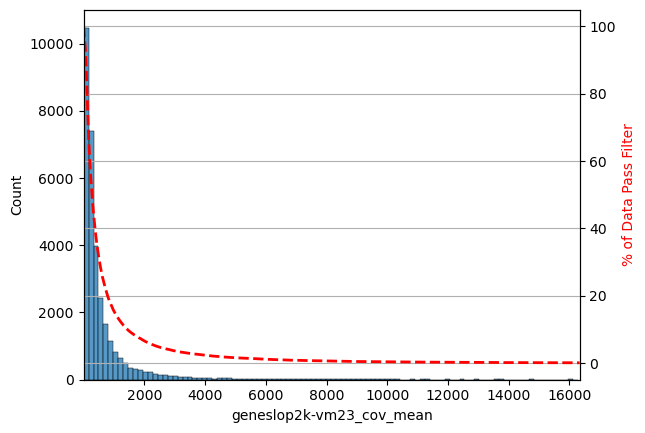

In [25]:
min_cov = 5
mcds.add_feature_cov_mean()

feature_cov_mean = mcds.coords[f'{var_dim}_cov_mean'].to_pandas()
use_features &= feature_cov_mean[feature_cov_mean > min_cov].index

print(f'{use_features.size} features remained')


In [26]:
use_features

Index(['ENSMUSG00000051951', 'ENSMUSG00000102343', 'ENSMUSG00000025900',
       'ENSMUSG00000025902', 'ENSMUSG00000104238', 'ENSMUSG00000104328',
       'ENSMUSG00000033845', 'ENSMUSG00000025903', 'ENSMUSG00000033813',
       'ENSMUSG00000002459',
       ...
       'ENSMUSG00000101533', 'ENSMUSG00000102045', 'ENSMUSG00000100492',
       'ENSMUSG00000099982', 'ENSMUSG00000101402', 'ENSMUSG00000100574',
       'ENSMUSG00000100608', 'ENSMUSG00000102011', 'ENSMUSG00000096178',
       'ENSMUSG00000096768'],
      dtype='object', length=27651)

In [27]:
mcds.filter_feature_by_cov_mean(min_cov=min_cov)


Before cov mean filter: 32208 geneslop2k-vm23
 After cov mean filter: 31425 geneslop2k-vm23 97.6%


<xarray.MCDS>
Dimensions:                   (cell: 50985, count_type: 2,
                               geneslop2k-vm23: 31425, mc_type: 2)
Coordinates:
  * cell                      (cell) <U15 '10D_M_19' '10D_M_23' ... '1A_M_1300'
  * count_type                (count_type) <U3 'mc' 'cov'
  * geneslop2k-vm23           (geneslop2k-vm23) <U18 'ENSMUSG00000051951' ......
    geneslop2k-vm23_chrom     (geneslop2k-vm23) <U5 'chr1' 'chr1' ... 'chrM'
    geneslop2k-vm23_cov_mean  (geneslop2k-vm23) float64 6.313e+03 ... 312.2
    geneslop2k-vm23_end       (geneslop2k-vm23) int64 3673498 3515553 ... 16299
    geneslop2k-vm23_start     (geneslop2k-vm23) int64 3203901 3464587 ... 12145
  * mc_type                   (mc_type) <U3 'CGN' 'CHN'
Data variables:
    geneslop2k-vm23_da        (cell, geneslop2k-vm23, mc_type, count_type) uint16 dask.array<chunksize=(1000, 31425, 1, 1), meta=np.ndarray>
    geneslop2k-vm23_da_frac   (cell, geneslop2k-vm23, mc_type) float32 dask.array<chunksize=(1000, 31425, 1), meta=np.ndarray>
Attributes:
    obs_dim:  cell
    var_dim:  geneslop2k-vm23

In [28]:
mcds

<xarray.MCDS>
Dimensions:                   (cell: 50985, count_type: 2,
                               geneslop2k-vm23: 32208, mc_type: 2)
Coordinates:
  * cell                      (cell) <U15 '10D_M_19' '10D_M_23' ... '1A_M_1300'
  * count_type                (count_type) <U3 'mc' 'cov'
  * geneslop2k-vm23           (geneslop2k-vm23) <U18 'ENSMUSG00000051951' ......
    geneslop2k-vm23_chrom     (geneslop2k-vm23) <U5 'chr1' 'chr1' ... 'chrM'
    geneslop2k-vm23_cov_mean  (geneslop2k-vm23) float64 6.313e+03 ... 312.2
    geneslop2k-vm23_end       (geneslop2k-vm23) int64 3673498 3515553 ... 16299
    geneslop2k-vm23_start     (geneslop2k-vm23) int64 3203901 3464587 ... 12145
  * mc_type                   (mc_type) <U3 'CGN' 'CHN'
Data variables:
    geneslop2k-vm23_da        (cell, geneslop2k-vm23, mc_type, count_type) uint16 dask.array<chunksize=(1000, 32208, 1, 1), meta=np.ndarray>
    geneslop2k-vm23_da_frac   (cell, geneslop2k-vm23, mc_type) float32 dask.array<chunksize=(1000, 32208, 1), meta=np.ndarray>
Attributes:
    obs_dim:  cell
    var_dim:  geneslop2k-vm23

In [29]:
mcds.add_mc_frac(normalize_per_cell=True, clip_norm_value=10)


In [30]:
mcds

<xarray.MCDS>
Dimensions:                   (cell: 50985, count_type: 2,
                               geneslop2k-vm23: 32208, mc_type: 2)
Coordinates:
  * cell                      (cell) <U15 '10D_M_19' '10D_M_23' ... '1A_M_1300'
  * count_type                (count_type) <U3 'mc' 'cov'
  * geneslop2k-vm23           (geneslop2k-vm23) <U18 'ENSMUSG00000051951' ......
    geneslop2k-vm23_chrom     (geneslop2k-vm23) <U5 'chr1' 'chr1' ... 'chrM'
    geneslop2k-vm23_cov_mean  (geneslop2k-vm23) float64 6.313e+03 ... 312.2
    geneslop2k-vm23_end       (geneslop2k-vm23) int64 3673498 3515553 ... 16299
    geneslop2k-vm23_start     (geneslop2k-vm23) int64 3203901 3464587 ... 12145
  * mc_type                   (mc_type) <U3 'CGN' 'CHN'
Data variables:
    geneslop2k-vm23_da        (cell, geneslop2k-vm23, mc_type, count_type) uint16 dask.array<chunksize=(1000, 32208, 1, 1), meta=np.ndarray>
    geneslop2k-vm23_da_frac   (cell, geneslop2k-vm23, mc_type) float64 dask.array<chunksize=(1000, 32208, 1), meta=np.ndarray>
Attributes:
    obs_dim:  cell
    var_dim:  geneslop2k-vm23

In [31]:
mcds = mcds[['geneslop2k-vm23_da_frac']]
mcds['geneslop2k-vm23_da_frac'] = mcds['geneslop2k-vm23_da_frac'].astype('float32')


In [32]:
mcds

<xarray.MCDS>
Dimensions:                   (cell: 50985, geneslop2k-vm23: 32208, mc_type: 2)
Coordinates:
  * cell                      (cell) <U15 '10D_M_19' '10D_M_23' ... '1A_M_1300'
  * geneslop2k-vm23           (geneslop2k-vm23) <U18 'ENSMUSG00000051951' ......
    geneslop2k-vm23_chrom     (geneslop2k-vm23) <U5 'chr1' 'chr1' ... 'chrM'
    geneslop2k-vm23_cov_mean  (geneslop2k-vm23) float64 6.313e+03 ... 312.2
    geneslop2k-vm23_end       (geneslop2k-vm23) int64 3673498 3515553 ... 16299
    geneslop2k-vm23_start     (geneslop2k-vm23) int64 3203901 3464587 ... 12145
  * mc_type                   (mc_type) <U3 'CGN' 'CHN'
Data variables:
    geneslop2k-vm23_da_frac   (cell, geneslop2k-vm23, mc_type) float32 dask.array<chunksize=(1000, 32208, 1), meta=np.ndarray>
Attributes:
    obs_dim:  cell
    var_dim:  geneslop2k-vm23

In [33]:
mcds

<xarray.MCDS>
Dimensions:                   (cell: 50985, geneslop2k-vm23: 32208, mc_type: 2)
Coordinates:
  * cell                      (cell) <U15 '10D_M_19' '10D_M_23' ... '1A_M_1300'
  * geneslop2k-vm23           (geneslop2k-vm23) <U18 'ENSMUSG00000051951' ......
    geneslop2k-vm23_chrom     (geneslop2k-vm23) <U5 'chr1' 'chr1' ... 'chrM'
    geneslop2k-vm23_cov_mean  (geneslop2k-vm23) float64 6.313e+03 ... 312.2
    geneslop2k-vm23_end       (geneslop2k-vm23) int64 3673498 3515553 ... 16299
    geneslop2k-vm23_start     (geneslop2k-vm23) int64 3203901 3464587 ... 12145
  * mc_type                   (mc_type) <U3 'CGN' 'CHN'
Data variables:
    geneslop2k-vm23_da_frac   (cell, geneslop2k-vm23, mc_type) float32 dask.array<chunksize=(1000, 32208, 1), meta=np.ndarray>
Attributes:
    obs_dim:  cell
    var_dim:  geneslop2k-vm23

In [ ]:
mcds.write_dataset('/data1st2/junyi/output/methlypub0823/geneslop2k-vm23_frac.mcds', var_dims=['geneslop2k-vm23'],mode='w')


Saving geneslop2k-vm23
Saving chunk 0: 0 - 5098


/home/junyichen/anaconda3/envs/allcools/lib/python3.8/site-packages/dask/core.py:119: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))


Saving chunk 1: 5098 - 10196


/home/junyichen/anaconda3/envs/allcools/lib/python3.8/site-packages/dask/core.py:119: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))


Saving chunk 2: 10196 - 15294


...

Saving chunk 9: 45882 - 50980


/home/junyichen/anaconda3/envs/allcools/lib/python3.8/site-packages/dask/core.py:119: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))


Saving chunk 10: 50980 - 50985


/home/junyichen/anaconda3/envs/allcools/lib/python3.8/site-packages/dask/core.py:119: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))


/home/junyichen/anaconda3/envs/allcools/lib/python3.8/site-packages/dask/core.py:119: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))


In [35]:
use_gene_meta = gene_meta.loc[use_features]
use_gene_meta.to_csv('/data1st2/junyi/output/methlypub0823/GeneMetadata.csv.gz')


In [36]:

mcg = mcds.get_adata(mc_type='CGN',var_dim='geneslop2k-vm23',obs_dim='cell')

select_hvf is True, but no highly variable feature results found, use all features instead.


/home/junyichen/anaconda3/envs/allcools/lib/python3.8/site-packages/dask/core.py:119: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))


In [37]:
mcg


AnnData object with n_obs × n_vars = 50985 × 32208
    var: 'chrom', 'cov_mean', 'end', 'start'

In [38]:
mcg.obs

""
cell
10D_M_19
10D_M_23
10D_M_39
10D_M_49
10D_M_64
...
8J_M_402
11D_M_1999
11E_M_610


In [39]:
mch = mcds.get_adata(mc_type='CHN',var_dim='geneslop2k-vm23',obs_dim='cell')

select_hvf is True, but no highly variable feature results found, use all features instead.


In [43]:
mch.obs

""
cell
10D_M_19
10D_M_23
10D_M_39
10D_M_49
10D_M_64
...
8J_M_402
11D_M_1999
11E_M_610


# Prepare L4 region level metadata

In [44]:
meta_data = df_mc_meta

In [45]:
meta_data.head()

,cell,mCCCFrac,mCGFrac,mCHFrac,FinalmCReads,DissectionRegion,Plate,Col384,Row384,Slice,...,InputReads,PassBasicQC,PlateNormCov,CEMBARegion,MajorRegion,SubRegion,CellGroup,SubClass,Class,NeuroTransmitters
0,10A_M_1,0.008874,0.819390,0.036336,1073981.0,RSP-4,CEMBA190423_10A_1,0,1,10,...,2252674,True,0.834409,10A,Isocortex,RSP,c18_c4_c1_c1_r0,L6b CTX Glut,NP-CT-L6b Glut,Glut
1,10A_M_100,0.007105,0.762382,0.019705,1108484.0,RSP-4,CEMBA190423_10A_2,0,3,10,...,2549478,True,0.842048,10A,Isocortex,RSP,c24_c0_c0_c0_r2,L2/3 IT RSP Glut,IT-ET Glut,Glut
2,10A_M_1000,0.006450,0.744689,0.016373,1443814.0,RSP-4,CEMBA190423_10A_4,7,5,10,...,3342484,True,1.031215,10A,Isocortex,RSP,c24_c0_c0_c0_r2,L2/3 IT RSP Glut,IT-ET Glut,Glut
3,10A_M_1001,0.007433,0.780743,0.029361,1372174.0,RSP-4,CEMBA190423_10A_3,8,4,10,...,3220214,True,0.942444,10A,Isocortex,RSP,c2_c3_c4_c2_r0,L6 CT CTX Glut,NP-CT-L6b Glut,Glut
4,10A_M_1002,0.006215,0.741165,0.018129,1650777.0,RSP-4,CEMBA190423_10A_3,8,5,10,...,3871980,True,1.133796,10A,Isocortex,RSP,c24_c0_c0_c0_r2,L2/3 IT RSP Glut,IT-ET Glut,Glut


In [46]:
meta_data.columns

Index(['cell', 'mCCCFrac', 'mCGFrac', 'mCHFrac', 'FinalmCReads',
       'DissectionRegion', 'Plate', 'Col384', 'Row384', 'Slice', 'Sample',
       'Technology', 'InputReads', 'PassBasicQC', 'PlateNormCov',
       'CEMBARegion', 'MajorRegion', 'SubRegion', 'CellGroup', 'SubClass',
       'Class', 'NeuroTransmitters'],
      dtype='object')

# Group metat for cell group level
- some are median 
- some are sum

In [47]:
df_mc_meta

,cell,mCCCFrac,mCGFrac,mCHFrac,FinalmCReads,DissectionRegion,Plate,Col384,Row384,Slice,...,InputReads,PassBasicQC,PlateNormCov,CEMBARegion,MajorRegion,SubRegion,CellGroup,SubClass,Class,NeuroTransmitters
0,10A_M_1,0.008874,0.819390,0.036336,1073981.0,RSP-4,CEMBA190423_10A_1,0,1,10,...,2252674,True,0.834409,10A,Isocortex,RSP,c18_c4_c1_c1_r0,L6b CTX Glut,NP-CT-L6b Glut,Glut
1,10A_M_100,0.007105,0.762382,0.019705,1108484.0,RSP-4,CEMBA190423_10A_2,0,3,10,...,2549478,True,0.842048,10A,Isocortex,RSP,c24_c0_c0_c0_r2,L2/3 IT RSP Glut,IT-ET Glut,Glut
2,10A_M_1000,0.006450,0.744689,0.016373,1443814.0,RSP-4,CEMBA190423_10A_4,7,5,10,...,3342484,True,1.031215,10A,Isocortex,RSP,c24_c0_c0_c0_r2,L2/3 IT RSP Glut,IT-ET Glut,Glut
3,10A_M_1001,0.007433,0.780743,0.029361,1372174.0,RSP-4,CEMBA190423_10A_3,8,4,10,...,3220214,True,0.942444,10A,Isocortex,RSP,c2_c3_c4_c2_r0,L6 CT CTX Glut,NP-CT-L6b Glut,Glut
4,10A_M_1002,0.006215,0.741165,0.018129,1650777.0,RSP-4,CEMBA190423_10A_3,8,5,10,...,3871980,True,1.133796,10A,Isocortex,RSP,c24_c0_c0_c0_r2,L2/3 IT RSP Glut,IT-ET Glut,Glut
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
301621,17A_M_3051,0.007412,0.747842,0.018610,1559491.0,CB-4,CEMBA210812_17A_4,1,14,17,...,4589584,True,1.090938,17A,CB,CBX,c21_c5_c2_c0_r1,CBX Purkinje Gaba,CB GABA,Gaba
301622,17A_M_3052,0.008806,0.830814,0.043916,1219087.0,CB-4,CEMBA210812_17A_4,0,15,17,...,3510150,True,0.852810,17A,CB,CBX,c36_c1_c0_c0_r1,CBX Golgi Gly-Gaba,CB GABA,Gly-Gaba
301623,17A_M_3053,0.006352,0.768759,0.023178,1723321.0,CB-4,CEMBA210812_17A_4,12,15,17,...,4903466,True,1.205545,17A,CB,CBX,c21_c5_c0_c0_r1,CBX Purkinje Gaba,CB GABA,Gaba
301624,17A_M_3054,0.006006,0.755818,0.018815,1673963.0,CB-4,CEMBA210812_17A_4,13,15,17,...,4773312,True,1.171017,17A,CB,CBX,c21_c0_c2_c0_r1,CBX Purkinje Gaba,CB GABA,Gaba


In [48]:
selected_df_meta

,cell,mCCCFrac,mCGFrac,mCHFrac,FinalmCReads,DissectionRegion,Plate,Col384,Row384,Slice,...,NeuroTransmitters,mc_all_tsne_0,mc_all_tsne_1,mc_all_umap_0,mc_all_umap_1,mr_tsne_0,mr_tsne_1,mr_tsne_0.1,mr_tsne_1.1,region
6944,10E_M_0,0.008198,0.822633,0.041640,1626504.0,CA-iii,CEMBA190625_10E_1,0,0,10,...,Gaba,2.307285,-44.389526,1.159059,11.305675,46.388546,-20.376892,46.388546,-20.376892,HPF
6945,10E_M_1,0.006019,0.743035,0.024127,2009998.0,CA-iii,CEMBA190625_10E_1,0,1,10,...,Glut,45.042800,39.051685,7.001616,17.043404,-40.395767,18.149730,-40.395767,18.149730,HPF
6946,10E_M_10,0.006569,0.750172,0.027665,1383636.0,CA-iii,CEMBA190625_10E_1,19,0,10,...,Glut,45.871723,38.445663,7.142896,16.882565,-37.318295,18.584543,-37.318295,18.584543,HPF
6947,10E_M_101,0.006353,0.760898,0.026547,2474670.0,CA-iii,CEMBA190625_10E_1,18,3,10,...,Glut,47.150690,36.516457,7.406974,16.432354,-29.483023,21.383305,-29.483023,21.383305,HPF
6948,10E_M_102,0.005409,0.752980,0.019497,2430290.0,CA-iii,CEMBA190625_10E_1,19,2,10,...,Glut,30.543667,26.955986,8.870768,11.923141,-41.245570,-4.188888,-41.245570,-4.188888,HPF
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
241936,13B_M_3063,0.006512,0.772815,0.024346,1623089.0,RHP-5,CEMBA201210_13B_3,7,14,13,...,Glut,22.151556,57.970783,16.106544,12.940551,34.033560,-65.110700,34.033560,-65.110700,HPF
241937,13B_M_3064,0.004420,0.779971,0.015408,2430961.0,RHP-5,CEMBA201210_13B_3,18,15,13,...,Glut,46.588436,6.865182,13.688123,6.910759,15.895534,-24.564827,15.895534,-24.564827,HPF
241938,13B_M_3065,0.006550,0.813182,0.029592,1365307.0,RHP-5,CEMBA201210_13B_3,19,15,13,...,Glut,14.779649,55.368393,15.568560,13.853018,22.595562,-54.189780,22.595562,-54.189780,HPF
241939,13B_M_3066,0.007224,0.782155,0.029679,1188728.0,RHP-5,CEMBA201210_13B_3,6,15,13,...,Glut,17.364103,-13.452222,12.878101,2.178544,-20.097544,-73.868370,-20.097544,-73.868370,HPF


In [49]:
mcg.obs = mcg.obs.merge(selected_df_meta,left_index=True,right_on='cell')    

/home/junyichen/anaconda3/envs/allcools/lib/python3.8/site-packages/anndata/_core/anndata.py:788: UserWarning: 
AnnData expects .obs.index to contain strings, but got values like:
    [227972, 227976, 227990, 227996, 228008]

    Inferred to be: integer

  value_idx = self._prep_dim_index(value.index, attr)


In [50]:
mcg.obs

,cell,mCCCFrac,mCGFrac,mCHFrac,FinalmCReads,DissectionRegion,Plate,Col384,Row384,Slice,...,NeuroTransmitters,mc_all_tsne_0,mc_all_tsne_1,mc_all_umap_0,mc_all_umap_1,mr_tsne_0,mr_tsne_1,mr_tsne_0.1,mr_tsne_1.1,region
227972,10D_M_19,0.007567,0.767896,0.024918,1058112.0,RHP-1,CEMBA201203_10D_5,1,4,10,...,Glut,56.078150,-16.586481,17.632769,2.143962,14.476485,-16.651365,14.476485,-16.651365,HPF
227976,10D_M_23,0.006579,0.759685,0.023441,960099.0,RHP-1,CEMBA201203_10D_5,1,5,10,...,Glut,53.899630,-17.386000,17.931927,1.131473,13.316872,-16.198483,13.316872,-16.198483,HPF
227990,10D_M_39,0.006851,0.768793,0.022733,937941.0,RHP-1,CEMBA201203_10D_5,1,9,10,...,Glut,55.774930,-18.350521,18.175043,1.446841,13.849258,-15.020651,13.849258,-15.020651,HPF
227996,10D_M_49,0.007518,0.762153,0.023334,785896.0,RHP-1,CEMBA201203_10D_5,12,12,10,...,Glut,54.974010,-18.406600,18.394384,1.421212,14.356843,-15.753139,14.356843,-15.753139,HPF
228008,10D_M_64,0.006438,0.765780,0.022757,1491961.0,RHP-1,CEMBA201203_10D_5,14,0,10,...,Glut,55.077990,-17.641394,18.129213,1.519717,13.998060,-16.327232,13.998060,-16.327232,HPF
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
152318,8J_M_402,0.003951,0.760012,0.009388,1648378.0,DG-1,CEMBA190711_8J_2,22,8,8,...,NN,-45.452670,43.692440,1.588859,-9.512807,49.885017,24.455810,49.885017,24.455810,HPF
20251,11D_M_1999,0.004225,0.734543,0.009898,1816189.0,RHP-2,CEMBA191031_11D_2,16,8,11,...,Glut,-0.274087,1.251536,-2.266489,-9.624870,33.303566,10.146790,33.303566,10.146790,HPF
23963,11E_M_610,0.004262,0.724660,0.009901,3005912.0,CA-iv,CEMBA190214_11E_1,3,13,11,...,Glut,-7.464271,2.059410,-2.652821,-8.794140,33.344220,10.155447,33.344220,10.155447,HPF
167558,9J_M_2201,0.003785,0.753118,0.010043,2161923.0,DG-2,CEMBA190219_9J_1,19,14,9,...,Glut,1.963346,0.461353,-2.402017,-9.852184,33.281420,10.123643,33.281420,10.123643,HPF


In [51]:
mcg.obsm['X_umap'] = mcg.obs[['mc_all_umap_0', 'mc_all_umap_1']].values


In [52]:
mch.obs = mch.obs.merge(selected_df_meta,left_index=True,right_on='cell')  

/home/junyichen/anaconda3/envs/allcools/lib/python3.8/site-packages/anndata/_core/anndata.py:788: UserWarning: 
AnnData expects .obs.index to contain strings, but got values like:
    [227972, 227976, 227990, 227996, 228008]

    Inferred to be: integer

  value_idx = self._prep_dim_index(value.index, attr)


In [53]:
mch.obsm['X_umap'] = mch.obs[['mc_all_umap_0', 'mc_all_umap_1']].values


/home/junyichen/anaconda3/envs/allcools/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


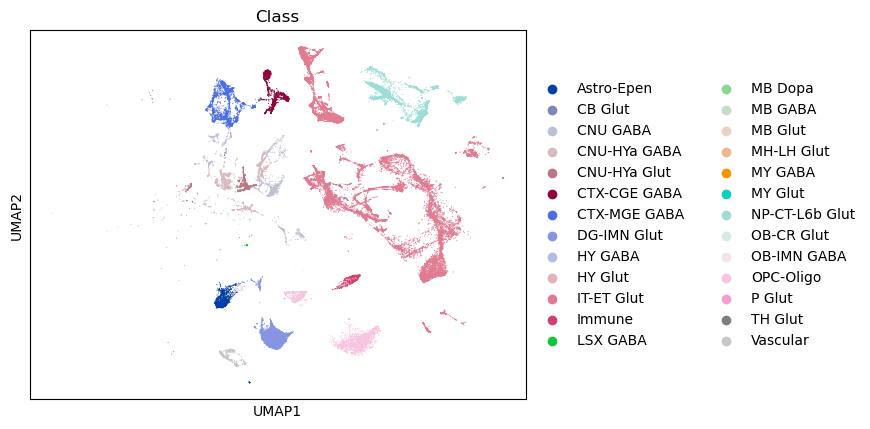

In [54]:
sc.pl.umap(mcg, color=['Class'], ncols=2)

/home/junyichen/anaconda3/envs/allcools/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


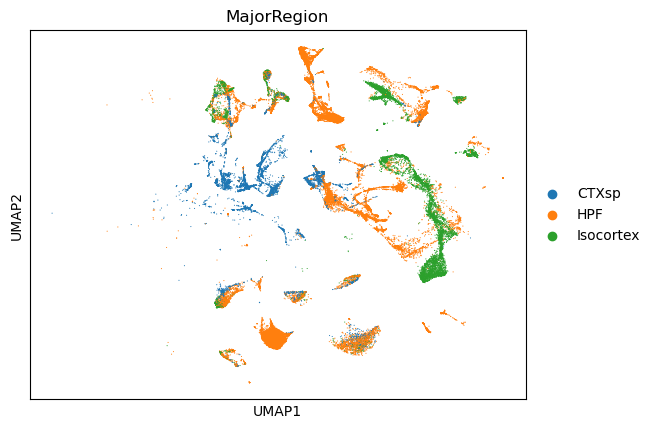

In [55]:
sc.pl.umap(mch, color=['MajorRegion'], ncols=2)

In [56]:
mcg.write_h5ad('/data1st2/junyi/output/methlypub0823/mcg_geneslop2k-vm23.h5ad')
mch.write_h5ad('/data1st2/junyi/output/methlypub0823/mch_geneslop2k-vm23.h5ad')

# Prepare the mcds file will 100k bin 

In [ ]:
var_dim = 'chrom100k'
mcds_bin = MCDS.open('/data2st1/junyi/methlyatlas/mCseq/data.nemoarchive.org/biccn/grant/u19_cemba/ecker/epigenome/cellgroup/mCseq3/mouse/processed/counts/CEMBA.snmC.mcds',
                   obs_dim='cell',var_dim=var_dim,use_obs=selected_df_meta.cell)

total_feature = mcds_bin.get_index(var_dim).size
mcds_bin


In [ ]:
selected_df_meta.set_index('cell',inplace=True)

In [ ]:
mcds_bin.add_cell_metadata(selected_df_meta)


In [ ]:
mcds_bin.add_feature_cov_mean(var_dim=var_dim)


In [ ]:

# feature cov cutoffs
min_cov = 500
max_cov = 3000
black_list_fraction = 0.2
black_list_path = mm10.ENCODE_BLACKLIST_PATH
exclude_chromosome = ['chrM']
# HVF
mch_pattern = 'CHN'
mcg_pattern = 'CGN'
n_top_feature = 20000

# PC cutoff
pc_cutoff = 0.1

# KNN
knn = -1  # -1 means auto determine

# Leiden
resolution = 1


# filter by coverage - based on the distribution above
mcds_bin = mcds_bin.filter_feature_by_cov_mean(
    min_cov=min_cov,  # minimum coverage
    max_cov=max_cov  # maximum coverage
)

# remove blacklist regions
mcds_bin = mcds_bin.remove_black_list_region(
    black_list_path=black_list_path,
    f=black_list_fraction  # Features having overlap > f with any black list region will be removed.
)

# remove chromosomes
mcds_bin = mcds_bin.remove_chromosome(exclude_chromosome)

In [ ]:
mcds_bin

In [ ]:
load = True
mcds_bin.add_mc_frac(
normalize_per_cell=True,  # after calculating mC frac, per cell normalize the matrix
    clip_norm_value=10  # clip outlier values above 10 to 10
)
obs_dim = 'cell'

# load only the mC fraction matrix into memory so following steps is faster
# Only load into memory when your memory size is enough to handle your dataset
if load and (mcds_bin.get_index(obs_dim).size < 20000):
    mcds_bin[f'{var_dim}_da_frac'].load()


In [ ]:
mch_bin_hvf = mcds_bin.calculate_hvf_svr(var_dim=var_dim,
                                 mc_type=mcg_pattern,
                                 n_top_feature=n_top_feature,
                                 plot=True)

In [ ]:
mcg_bin_adata = mcds_bin.get_adata(mc_type=mcg_pattern,
                           var_dim=var_dim,
                           select_hvf=True)
mcg_bin_adata


In [ ]:
mcg_bin_adata.obs.head()

In [ ]:
from ALLCools.clustering import tsne, significant_pc_test, log_scale
from ALLCools.plot import *

In [ ]:
mcg_bin_adata

In [ ]:
log_scale(mcg_bin_adata)


In [ ]:
mcg_col_name = 'mCGFrac'  # Name may change

sc.tl.pca(mcg_bin_adata)
cg_n_components = significant_pc_test(mcg_bin_adata)
fig, axes = plot_decomp_scatters(mcg_bin_adata,
                                 n_components=cg_n_components,
                                 hue=mcg_col_name,
                                 hue_quantile=(0.25, 0.75),
                                 nrows=3,
                                 ncols=5)

In [ ]:
mch_hvf = mcds_bin.calculate_hvf_svr(var_dim=var_dim,
                                 mc_type=mch_pattern,
                                 n_top_feature=n_top_feature,
                                 plot=True)


In [ ]:
mch_bin_adata = mcds_bin.get_adata(mc_type=mch_pattern,
                           var_dim=var_dim,
                           select_hvf=True)
mch_bin_adata


In [ ]:
mch_bin_adata

In [ ]:
mch_col_name = "mCHFrac"
sc.tl.pca(mch_bin_adata)
ch_n_components = significant_pc_test(mch_bin_adata)
fig, axes = plot_decomp_scatters(mch_bin_adata,
                                 n_components=ch_n_components,
                                 hue=mch_col_name,
                                 hue_quantile=(0.25, 0.75),
                                 nrows=3,
                                 ncols=5)

In [ ]:
import numpy as np
ch_pcs = mch_bin_adata.obsm['X_pca'][:, :ch_n_components]
cg_pcs = mcg_bin_adata.obsm['X_pca'][:, :cg_n_components]

cg_pcs = cg_pcs / cg_pcs.std()
ch_pcs = ch_pcs / ch_pcs.std()

# total_pcs
total_pcs = np.hstack([ch_pcs, cg_pcs])

# make a copy of adata, add new pcs
# this is suboptimal, will change this when adata can combine layer and X in the future
adata_merged = mch_bin_adata.copy()
adata_merged.obsm['X_pca'] = total_pcs


In [ ]:
adata_merged

In [ ]:
if knn == -1:
    knn = max(15, int(np.log2(adata_merged.shape[0])*2))


In [ ]:
sc.pp.neighbors(adata_merged, n_neighbors=knn)


In [ ]:
sc.tl.leiden(adata_merged, resolution=resolution)


In [ ]:
sc.tl.umap(adata_merged)



In [ ]:
fig, ax = plt.subplots(figsize=(4, 4), dpi=300)
_ = categorical_scatter(data=adata_merged,
                        ax=ax,
                        coord_base='umap',
                        hue='leiden',
                        text_anno='leiden',
                        show_legend=True)


In [ ]:
fig, ax = plt.subplots(figsize=(4, 4), dpi=300)
_ = categorical_scatter(data=adata_merged,
                        ax=ax,
                        coord_base='umap',
                        hue='Class',
                        text_anno='Class',
                        show_legend=True)


In [ ]:
fig, ax = plt.subplots(figsize=(4, 4), dpi=300)
_ = categorical_scatter(data=adata_merged,
                        ax=ax,
                        coord_base='umap',
                        hue='leiden',
                        text_anno='leiden',
                        show_legend=True)

In [ ]:
pd.DataFrame(set(adata_merged.obs['SubClass'])).to_csv('output/subclass.csv.gz')

In [ ]:
interactive_scatter(data=mcg,
                    hue='Class',
                    coord_base='umap',
                    max_points=3000)

In [ ]:
interactive_scatter(data=adata_merged,
                    hue='Class',
                    coord_base='umap',
                    max_points=3000)

In [ ]:
adata_sc.obs.columns

In [ ]:
map_subclass_class = dict(zip(adata_merged.obs['SubClass'], adata_merged.obs['Class']))

In [ ]:
cell_class = adata_sc.obs['pred_mwb'].str.replace(r'^\d+\s', '')
convert_class = []
for i in range(0,len(cell_class)):
    cc = cell_class[i] 
    if cc not in map_subclass_class:
        convert_class.append(cc)
    else:
        convert_class.append(map_subclass_class[cc])   


In [ ]:
adata_sc.obs['pred_Class'] = convert_class

In [ ]:
interactive_scatter(data=adata_sc,
                    hue='pred_mwb',
                    coord_base='umap',
                    max_points=3000)

In [ ]:
interactive_scatter(data=adata_sc,
                    hue='pred_Class',
                    coord_base='umap',
                    max_points=3000)

In [ ]:
interactive_scatter(data=adata_merged,
                    hue='leiden',
                    coord_base='umap',
                    max_points=5000)

In [ ]:
sc.pl.umap(mcg, color=['Class'], ncols=2)

In [ ]:
adata_merged.write_h5ad('output/Brain-pfc-chrom100k-clustering.h5ad')
adata_merged


In [ ]:
adata_merged.obs.to_csv('output/Brain-pfc-ClusteringResults.csv.gz')
adata_merged.obs.head()


In [ ]:
mcds

In [ ]:
n_genes =10000

In [ ]:
sc.pp.highly_variable_genes(mcg, n_top_genes=n_genes, n_bins=20)

In [ ]:
sc.pp.highly_variable_genes(mch, n_top_genes=n_genes, n_bins=20)

In [ ]:
adata_raw = sc.read_10x_mtx("/data1st1/seq_from_our_lab/NovaSeq_mmBrain_X101SC24104268-Z01/X101SC24104268-Z01-J001/seeksoul_output/W1/step3/filtered_feature_bc_matrix")

In [ ]:
adata_raw.var

In [ ]:
adata_sc.var['gane_name'] = adata_sc.var.index

In [ ]:
adata_sc.var

In [ ]:
var_merged = adata_raw.var.merge(adata_sc.var,how='outer',left_index=True,right_index=True,indicator=True)
var_merged

In [ ]:
adata_sc.var.index

In [ ]:
adata_sc.var = var_merged.loc[adata_sc.var.index]

In [ ]:
adata_sc.var.set_index('gene_ids',inplace=True)

In [ ]:
adata_atac_gene = adata.read_h5ad('/data2st1/junyi/snATAC_02_matrix/WT_PFC_W26_geneactivity_n.h5ad')
adata_atac_bin = adata.read_h5ad('/data2st1/junyi/snATAC_02_matrix/WT_PFC_W26_5kb.h5ad')

In [ ]:
pcs = pd.read_csv('/data2st1/junyi/snATAC_02_matrix/combined_atac_QC_reduction_pcs.csv',index_col=0)

In [ ]:
pcs.index

In [ ]:
len(set("WT_"+adata_atac_bin.obs.index).intersection(set(pcs.index)))

In [ ]:
adata_atac_bin.obs.index = "WT_"+adata_atac_bin.obs.index

In [ ]:
adata_atac_gene.obs.index = "WT_"+adata_atac_gene.obs.index

In [ ]:
adata_atac_gene

In [ ]:
merge_barcode = adata_atac_gene.obs.merge(pcs,left_index=True,right_index=True,how='inner')

In [ ]:
adata_atac_selected = adata_atac_gene[merge_barcode.index]

In [ ]:
adata_atac_selected.obsm['X_pca'] = pcs.loc[merge_barcode.index].iloc[:,1:].values
# Ignore the first pc 

In [ ]:
adata_atac_selected.obsm['X_pca'].shape

In [ ]:
adata_atac_selected

In [ ]:
adata_atac_selected.obs.head()

In [ ]:
df_atac_umapdf_atac_umap = pd.read_csv('/data2st1/junyi/snATAC_02_matrix/combined_atac_QC_reduction_umap.csv',index_col=0)
adata_atac_selected.obsm['X_umap_seurat'] = df_atac_umapdf_atac_umap.loc[merge_barcode.index].values

In [ ]:
def dump_embedding(adata, name, n_dim=2):
    # put manifold coordinates into adata.obs
    for i in range(n_dim):
        adata.obs[f'{name}_{i}'] = adata.obsm[f'X_{name}'][:, i]
    return


In [ ]:
sc.pp.neighbors(adata_atac_selected)
sc.tl.leiden(adata_atac_selected, resolution=1)
sc.tl.umap(adata_atac_selected)
dump_embedding(adata_atac_selected, 'umap')


In [ ]:
dump_embedding(adata_atac_selected, 'umap')
dump_embedding(adata_atac_selected, 'umap_seurat')


In [ ]:
fig, axes = plt.subplots(figsize=(12, 4), dpi=250, ncols=2)

ax = axes[0]
_ = categorical_scatter(data=adata_atac_selected.obs,
                        ax=ax,
                        coord_base='umap',
                        hue='leiden',
                        palette='tab20',
                        text_anno='leiden')
ax = axes[1]
_ = categorical_scatter(data=adata_atac_selected.obs,
                        ax=ax,
                        coord_base='umap_seurat',
                        hue='leiden',
                        palette='tab20',
                        text_anno='leiden')



In [ ]:
n_components = significant_pc_test(adata_atac_selected)


In [ ]:
fig, axes = plot_decomp_scatters(adata_atac_selected,
                                 n_components=n_components,
                                 hue=None,
                                 hue_quantile=(0.25, 0.75),
                                 nrows=5,
                                 ncols=5)

In [ ]:
# n_genes = 10000
sc.pp.highly_variable_genes(adata_atac_selected, n_top_genes=n_genes, n_bins=20) 

In [ ]:
adata_atac_selected.var['gene_id'] = adata_atac_selected.var.index.str.split('.').str[0]

In [ ]:
adata_atac_selected.var.set_index('gene_id',inplace=True)

In [ ]:
sc_hvf_list = adata_sc.var['variances_norm'].sort_values(ascending=False).dropna()[:n_genes].index


In [ ]:
mcg_hvf_list = mcg.var['dispersions_norm'].sort_values(ascending=False).dropna()[:n_genes].index


In [ ]:
mch_hvf_list = mch.var['dispersions_norm'].sort_values(ascending=False).dropna()[:n_genes].index

In [ ]:
atac_hvf_list = adata_atac_selected.var['dispersions_norm'].sort_values(ascending=False).dropna()[:n_genes].index


In [ ]:
hvfs = mcg_hvf_list.intersection(sc_hvf_list).intersection(mcg_hvf_list).intersection(atac_hvf_list)

In [ ]:
len(hvfs)

In [ ]:
adata_sc_selected = adata_sc[(adata_sc.obs.tech == '10x') & (adata_sc.obs.group == 'W')]


In [ ]:
adata_sc_selected

In [ ]:
sc_hvf_adata = adata_sc_selected[:,hvfs].copy()
sc.pp.scale(sc_hvf_adata)
sc_hvf_adata

In [ ]:
mcg.var.index = mcg.var.index.astype(str)
mcg.obs.index = mcg.obs.index.astype(str)
mch.var.index = mch.var.index.astype(str)
mch.obs.index = mch.obs.index.astype(str)

In [ ]:
mcg_hvf_adata = mcg[:,hvfs].copy()
sc.pp.scale(mcg_hvf_adata)
mcg_hvf_adata.X *=-1

In [ ]:
mch_hvf_adata = mch[:,hvfs].copy()
sc.pp.scale(mch_hvf_adata)
mch_hvf_adata.X *=-1

In [ ]:
atac_hvf_adata = adata_atac_selected[:,hvfs].copy()
sc.pp.scale(atac_hvf_adata)

In [ ]:
adata_concat = sc_hvf_adata.concatenate([
    mcg_hvf_adata,
    mch_hvf_adata,
    atac_hvf_adata
    
],
                                index_unique='-')
adata_concat.obs['batch'] = adata_concat.obs['batch'].map({
    '0': 'sc',
    '1': 'mcg',
    '2': 'mch',
    '3': 'atac'
    })
adata_concat

In [ ]:
sc.pp.pca(adata_concat, n_comps=50)
sc.pl.pca_variance_ratio(adata_concat)
n_components = significant_pc_test(adata_concat, p_cutoff=0.2)


In [ ]:
adata_concat.obs['predicted_doublet'].fillna('False',inplace=True)
adata_concat.obs["predicted_doublet"] = adata_concat.obs["predicted_doublet"].astype(bool)

adata_concat.var['mt-0'] = adata_concat.var["mt-0"].astype(bool)
adata_concat.var['highly_variable-0-0'] = adata_concat.var["highly_variable-0-0"].astype(bool)
adata_concat.var['highly_variable-1-0'] = adata_concat.var["highly_variable-1-0"].astype(bool)
adata_concat.var['highly_variable-0'] = adata_concat.var["highly_variable-0"].astype(bool)

adata_concat.obs['PassBasicQC'] = adata_concat.obs["PassBasicQC"].astype(bool)


In [ ]:
adata_concat.write_h5ad('output/merged-PFC-concat-clustering.h5ad')

In [ ]:
ho = run_harmony(adata_concat.obsm['X_pca'],
                 meta_data=pd.DataFrame(adata_concat.obs['batch']),
                 vars_use='batch',
                 random_state=0,
                 nclust=100,
                 max_iter_harmony=20)
#adata_concat.obsm['X_pca'] = ho.Z_corr.T


In [ ]:
adata_concat.write_h5ad('output/merged-harmony-clustering.h5ad')

In [ ]:
adata_concat.obsm['X_pca'] = ho.Z_corr.T


In [ ]:
sc.pp.neighbors(adata_concat, n_neighbors=5)
sc.tl.leiden(adata_concat, resolution=1.5)
sc.tl.umap(adata_concat)


In [ ]:
_ = plot_decomp_scatters(adata_concat,
                         n_components=n_components,
                         hue='batch',
                         palette='tab10')

In [ ]:
adata_concat.obs['umap_0'] = adata_concat.obsm['X_umap'][:, 0]
adata_concat.obs['umap_1'] = adata_concat.obsm['X_umap'][:, 1]


In [ ]:
fig, axes = plt.subplots(figsize=(8, 3), dpi=250, ncols=2)

ax = axes[0]
categorical_scatter(ax=ax,
                    data=adata_concat,
                    hue='batch',
                    show_legend=True,
                    max_points=None,
                    s=1)

ax = axes[1]
categorical_scatter(ax=ax,
                    data=adata_concat,
                    hue='pred_Class',
                    show_legend=True,
                    max_points=None,
                    s=1)

In [ ]:
adata_concat.obs.columns

In [ ]:
adata_concat.obs[adata_concat.obs['batch'] == 'mcg'].copy().columns

In [ ]:
fig, axes = plt.subplots(figsize=(8, 3), dpi=250, ncols=2)

data = adata_concat.obs[adata_concat.obs['batch'] == 'mcg'].copy()
#data['MajorType'] = data['SubType'].str.split('_').str[-1]
data2 = adata_concat.obs[adata_concat.obs['batch'] == 'atac'].copy()


ax = axes[0]
categorical_scatter(ax=ax,
                    data=data,
                    show_legend=False,
                    max_points=None,
                    hue='SubRegion',
                    text_anno='SubRegion',
                    s=1)

ax = axes[1]
categorical_scatter(ax=ax,
                    data=data2,
                    hue='leiden',
                    show_legend=True,
                    text_anno='leiden',

                    max_points=None,
                    s=1)

In [ ]:
adata_sc.obs.columns

In [ ]:
df_pred_class=pd.DataFrame(pd.crosstab(adata_concat.obs['pred_Class'], adata_concat.obs['leiden']).idxmax())

In [ ]:
df_class=pd.DataFrame(pd.crosstab(adata_concat.obs['Class'], adata_concat.obs['leiden']).idxmax())

In [ ]:
df_type_merged = df_pred_class.merge(df_class,how='outer',left_index=True,right_index=True).fillna(method='ffill').fillna(method='bfill')
df_type_merged.columns = ['pred_Class','Class']

In [ ]:
lei_map_class = dict(zip(df_type_merged.index,df_type_merged['Class']))
lei_map_pred_class = dict(zip(df_type_merged.index,df_type_merged['pred_Class']))

In [ ]:
adata_concat.obs

In [ ]:
adata_concat.obs

In [ ]:
mapped_class = []
mappled_preclass = []
for inde,row in (adata_concat.obs).iterrows():
    if row['leiden'] not in lei_map_class:
        mapped_class.append(row['leiden'])
        mappled_preclass.append(row['leiden'])
    else:
        mapped_class.append(lei_map_class[row['leiden']])
        mappled_preclass.append(lei_map_pred_class[row['leiden']])  


In [ ]:
adata_concat.obs['mapped_class'] = mapped_class
adata_concat.obs['mappled_preclass'] = mappled_preclass

In [ ]:
interactive_scatter(data=adata_concat,
                    hue='mappled_preclass',
                    coord_base='umap',
                    max_points=20000)

In [ ]:
interactive_scatter(data=adata_concat,
                    hue='mappled_preclass',
                    coord_base='umap',
                    max_points=10000)

In [ ]:
adata_concat.obs

In [ ]:
sc._utils.sanitize_anndata(adata_concat)

In [ ]:
adata_concat.obs['predicted_doublet'].fillna('False',inplace=True)
adata_concat.obs["predicted_doublet"] = adata_concat.obs["predicted_doublet"].astype(bool)

adata_concat.var['mt-0'] = adata_concat.var["mt-0"].astype(bool)
adata_concat.var['highly_variable-0-0'] = adata_concat.var["highly_variable-0-0"].astype(bool)
adata_concat.var['highly_variable-1-0'] = adata_concat.var["highly_variable-1-0"].astype(bool)
adata_concat.var['highly_variable-0'] = adata_concat.var["highly_variable-0"].astype(bool)


In [ ]:
adata_concat.write_h5ad('output/merged-clustering.h5ad')